# Análisis Exploratorio de Datos (EDA) - Proyecto MLOps

**Objetivo:** Realizar un EDA completo con funciones genéricas y reutilizables para cualquier dataset tabular.

**Flujo del EDA:**
1. Descripción General del Dataset
2. Clasificación de Variables
3. Manejo de Valores Nulos
4. Limpieza y Validación de Datos
5. Análisis Univariable
6. Análisis Bivariable y Multivariable
7. Definición de Reglas de Validación
8. Recomendaciones para Feature Engineering

## 0. Setup e Importación de Librerías

In [1]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import List, Dict, Tuple, Optional, Union
from scipy import stats
from scipy.stats import normaltest, skew, kurtosis, chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Configurar rutas
PROJECT_ROOT = Path.cwd().parent.parent
DATA_PATH = PROJECT_ROOT / 'data' / 'raw' / 'Churn_Modelling.csv'

print("✓ Librerías cargadas correctamente")

✓ Librerías cargadas correctamente


## 1. Funciones Genéricas y Reutilizables para EDA

In [2]:
def load_and_describe_dataset(file_path: Union[str, Path]) -> pd.DataFrame:
    """
    Carga un dataset y muestra información general.
    
    Args:
        file_path: Ruta al archivo CSV
    
    Returns:
        DataFrame cargado
    """
    df = pd.read_csv(file_path)
    
    print("="*70)
    print("DESCRIPCIÓN GENERAL DEL DATASET")
    print("="*70)
    print(f"\nDimensiones: {df.shape[0]:,} filas x {df.shape[1]} columnas")
    print(f"Memoria utilizada: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    print(f"\nPrimeras filas del dataset:\n")
    display(df.head(3))
    
    return df

In [3]:
def classify_variables(df: pd.DataFrame, 
                       target_col: Optional[str] = None) -> Dict[str, List[str]]:
    """
    Clasifica automáticamente las variables del dataset.
    
    Args:
        df: DataFrame a analizar
        target_col: Nombre de la variable objetivo (si existe)
    
    Returns:
        Diccionario con la clasificación de variables
    """
    classification = {
        'numerical_continuous': [],
        'numerical_discrete': [],
        'categorical_nominal': [],
        'categorical_binary': [],
        'identifier': [],
        'target': []
    }
    
    for col in df.columns:
        # Identificar variable objetivo
        if target_col and col == target_col:
            classification['target'].append(col)
            continue
        
        # Identificar identificadores únicos
        if df[col].nunique() == len(df) or col.lower() in ['id', 'index', 'rownumber', 'customerid']:
            classification['identifier'].append(col)
            continue
        
        # Clasificar por tipo de dato
        if df[col].dtype in ['int64', 'float64']:
            unique_vals = df[col].nunique()
            total_vals = len(df)
            
            # Variable binaria numérica
            if unique_vals == 2:
                classification['categorical_binary'].append(col)
            # Variable discreta (pocos valores únicos)
            elif unique_vals < 10 or (unique_vals / total_vals) < 0.05:
                classification['numerical_discrete'].append(col)
            # Variable continua
            else:
                classification['numerical_continuous'].append(col)
        else:
            # Variables categóricas
            unique_vals = df[col].nunique()
            if unique_vals == 2:
                classification['categorical_binary'].append(col)
            else:
                classification['categorical_nominal'].append(col)
    
    # Mostrar resultados
    print("\n" + "="*70)
    print("CLASIFICACIÓN DE VARIABLES")
    print("="*70)
    for var_type, cols in classification.items():
        if cols:
            print(f"\n{var_type.upper().replace('_', ' ')} ({len(cols)}):")
            for col in cols:
                print(f"  - {col}")
    
    return classification

In [4]:
def analyze_missing_values(df: pd.DataFrame) -> pd.DataFrame:
    """
    Analiza valores nulos y caracteres especiales que representan nulos.
    
    Args:
        df: DataFrame a analizar
    
    Returns:
        DataFrame con resumen de valores nulos
    """
    print("\n" + "="*70)
    print("ANÁLISIS DE VALORES NULOS")
    print("="*70)
    
    missing_summary = pd.DataFrame({
        'Tipo_Dato': df.dtypes,
        'Nulos': df.isnull().sum(),
        'Porcentaje_Nulos': (df.isnull().sum() / len(df)) * 100,
        'Valores_Unicos': df.nunique()
    })
    
    # Detectar caracteres especiales que pueden representar nulos
    special_null_chars = ['?', '-', 'N/A', 'NA', 'null', 'NULL', 'None', '']
    special_nulls = {}
    
    for col in df.select_dtypes(include=['object']).columns:
        special_count = df[col].isin(special_null_chars).sum()
        if special_count > 0:
            special_nulls[col] = special_count
    
    if special_nulls:
        print("\n⚠ ADVERTENCIA: Se detectaron caracteres especiales que podrían ser nulos:")
        for col, count in special_nulls.items():
            print(f"  - {col}: {count} valores especiales")
    
    # Mostrar solo columnas con nulos
    missing_cols = missing_summary[missing_summary['Nulos'] > 0]
    if not missing_cols.empty:
        print("\nColumnas con valores nulos:\n")
        display(missing_cols)
    else:
        print("\n✓ No se detectaron valores nulos explícitos")
    
    return missing_summary

In [5]:
def clean_and_standardize_data(df: pd.DataFrame, 
                               columns_to_remove: Optional[List[str]] = None) -> pd.DataFrame:
    """
    Limpia y estandariza el dataset.
    
    Args:
        df: DataFrame a limpiar
        columns_to_remove: Lista de columnas a eliminar
    
    Returns:
        DataFrame limpio
    """
    df_clean = df.copy()
    
    print("\n" + "="*70)
    print("LIMPIEZA Y ESTANDARIZACIÓN")
    print("="*70)
    
    # 1. Eliminar columnas irrelevantes
    if columns_to_remove:
        df_clean = df_clean.drop(columns=columns_to_remove, errors='ignore')
        print(f"\n✓ Columnas eliminadas: {columns_to_remove}")
    
    # 2. Reemplazar caracteres especiales por np.nan
    special_null_chars = ['?', '-', 'N/A', 'NA', 'null', 'NULL', 'None', '']
    df_clean = df_clean.replace(special_null_chars, np.nan)
    print("✓ Caracteres especiales estandarizados a np.nan")
    
    # 3. Convertir tipos de datos correctamente
    for col in df_clean.columns:
        # Intentar convertir a numérico si es posible
        if df_clean[col].dtype == 'object':
            try:
                df_clean[col] = pd.to_numeric(df_clean[col])
            except (ValueError, TypeError):
                pass
    
    print("✓ Tipos de datos ajustados")
    
    # 4. Eliminar duplicados
    duplicates = df_clean.duplicated().sum()
    if duplicates > 0:
        df_clean = df_clean.drop_duplicates()
        print(f"✓ {duplicates} filas duplicadas eliminadas")
    
    print(f"\nDimensiones finales: {df_clean.shape[0]:,} filas x {df_clean.shape[1]} columnas")
    
    return df_clean

In [6]:
def univariate_numerical_analysis(df: pd.DataFrame, 
                                  numerical_cols: List[str],
                                  figsize: Tuple[int, int] = (15, 5)) -> Dict:
    """
    Análisis univariable de variables numéricas.
    
    Args:
        df: DataFrame a analizar
        numerical_cols: Lista de columnas numéricas
        figsize: Tamaño de las figuras
    
    Returns:
        Diccionario con estadísticas
    """
    stats_dict = {}
    
    for col in numerical_cols:
        data = df[col].dropna()
        
        print("\n" + "="*70)
        print(f"ANÁLISIS UNIVARIABLE: {col}")
        print("="*70)
        
        # Estadísticas descriptivas
        stats = {
            'Media': data.mean(),
            'Mediana': data.median(),
            'Moda': data.mode()[0] if not data.mode().empty else np.nan,
            'Desv_Std': data.std(),
            'Varianza': data.var(),
            'Rango': data.max() - data.min(),
            'IQR': data.quantile(0.75) - data.quantile(0.25),
            'Skewness': skew(data),
            'Kurtosis': kurtosis(data),
            'Min': data.min(),
            'Q1': data.quantile(0.25),
            'Q3': data.quantile(0.75),
            'Max': data.max()
        }
        
        stats_dict[col] = stats
        
        # Mostrar estadísticas
        print("\nEstadísticas Descriptivas:")
        for key, value in stats.items():
            print(f"  {key:.<20} {value:.4f}")
        
        # Interpretación de distribución
        if abs(stats['Skewness']) < 0.5:
            distribution = "aproximadamente simétrica"
        elif stats['Skewness'] > 0.5:
            distribution = "sesgada a la derecha (positiva)"
        else:
            distribution = "sesgada a la izquierda (negativa)"
        
        print(f"\n  → Distribución: {distribution}")
        
        # Visualización
        fig, axes = plt.subplots(1, 3, figsize=figsize)
        
        # Histograma
        axes[0].hist(data, bins=30, edgecolor='black', alpha=0.7)
        axes[0].axvline(stats['Media'], color='red', linestyle='--', label=f"Media: {stats['Media']:.2f}")
        axes[0].axvline(stats['Mediana'], color='green', linestyle='--', label=f"Mediana: {stats['Mediana']:.2f}")
        axes[0].set_title(f'Histograma - {col}')
        axes[0].set_xlabel(col)
        axes[0].set_ylabel('Frecuencia')
        axes[0].legend()
        
        # Boxplot
        axes[1].boxplot(data, vert=True)
        axes[1].set_title(f'Boxplot - {col}')
        axes[1].set_ylabel(col)
        
        # Q-Q plot
        stats.probplot(data, dist="norm", plot=axes[2])
        axes[2].set_title(f'Q-Q Plot - {col}')
        
        plt.tight_layout()
        plt.show()
    
    return stats_dict

In [7]:
from scipy.stats import probplot

def univariate_numerical_analysis(df: pd.DataFrame, 
                                  numerical_cols: List[str],
                                  figsize: Tuple[int, int] = (15, 5)) -> Dict:
    """
    Análisis univariable de variables numéricas.
    
    Args:
        df: DataFrame a analizar
        numerical_cols: Lista de columnas numéricas
        figsize: Tamaño de las figuras
    
    Returns:
        Diccionario con estadísticas
    """
    stats_dict = {}
    
    for col in numerical_cols:
        data = df[col].dropna()
        
        print("\n" + "="*70)
        print(f"ANÁLISIS UNIVARIABLE: {col}")
        print("="*70)
        
        # Estadísticas descriptivas
        stats = {
            'Media': data.mean(),
            'Mediana': data.median(),
            'Moda': data.mode()[0] if not data.mode().empty else np.nan,
            'Desv_Std': data.std(),
            'Varianza': data.var(),
            'Rango': data.max() - data.min(),
            'IQR': data.quantile(0.75) - data.quantile(0.25),
            'Skewness': skew(data),
            'Kurtosis': kurtosis(data),
            'Min': data.min(),
            'Q1': data.quantile(0.25),
            'Q3': data.quantile(0.75),
            'Max': data.max()
        }
        
        stats_dict[col] = stats
        
        # Mostrar estadísticas
        print("\nEstadísticas Descriptivas:")
        for key, value in stats.items():
            print(f"  {key:.<20} {value:.4f}")
        
        # Interpretación de distribución
        if abs(stats['Skewness']) < 0.5:
            distribution = "aproximadamente simétrica"
        elif stats['Skewness'] > 0.5:
            distribution = "sesgada a la derecha (positiva)"
        else:
            distribution = "sesgada a la izquierda (negativa)"
        
        print(f"\n  → Distribución: {distribution}")
        
        # Visualización
        fig, axes = plt.subplots(1, 3, figsize=figsize)
        
        # Histograma
        axes[0].hist(data, bins=30, edgecolor='black', alpha=0.7)
        axes[0].axvline(stats['Media'], color='red', linestyle='--', label=f"Media: {stats['Media']:.2f}")
        axes[0].axvline(stats['Mediana'], color='green', linestyle='--', label=f"Mediana: {stats['Mediana']:.2f}")
        axes[0].set_title(f'Histograma - {col}')
        axes[0].set_xlabel(col)
        axes[0].set_ylabel('Frecuencia')
        axes[0].legend()
        
        # Boxplot
        axes[1].boxplot(data, vert=True)
        axes[1].set_title(f'Boxplot - {col}')
        axes[1].set_ylabel(col)
        
        # Q-Q plot - FIXED: use probplot function instead of stats.probplot
        probplot(data, dist="norm", plot=axes[2])
        axes[2].set_title(f'Q-Q Plot - {col}')
        
        plt.tight_layout()
        plt.show()
    
    return stats_dict

In [8]:
def univariate_categorical_analysis(df: pd.DataFrame, 
                                   categorical_cols: List[str],
                                   figsize: Tuple[int, int] = (10, 5)) -> Dict:
    """
    Análisis univariable de variables categóricas.
    
    Args:
        df: DataFrame a analizar
        categorical_cols: Lista de columnas categóricas
        figsize: Tamaño de las figuras
    
    Returns:
        Diccionario con frecuencias
    """
    freq_dict = {}
    
    for col in categorical_cols:
        print("\n" + "="*70)
        print(f"ANÁLISIS UNIVARIABLE: {col}")
        print("="*70)
        
        # Frecuencias absolutas y relativas
        freq_abs = df[col].value_counts()
        freq_rel = df[col].value_counts(normalize=True) * 100
        
        freq_table = pd.DataFrame({
            'Frecuencia': freq_abs,
            'Porcentaje': freq_rel
        })
        
        freq_dict[col] = freq_table
        
        print(f"\nDistribución de {col}:\n")
        display(freq_table)
        
        # Visualización
        fig, axes = plt.subplots(1, 2, figsize=figsize)
        
        # Gráfico de barras
        freq_abs.plot(kind='bar', ax=axes[0], edgecolor='black', alpha=0.7)
        axes[0].set_title(f'Frecuencia - {col}')
        axes[0].set_xlabel(col)
        axes[0].set_ylabel('Frecuencia')
        axes[0].tick_params(axis='x', rotation=45)
        
        # Gráfico de pastel (solo si hay pocas categorías)
        if len(freq_abs) <= 10:
            axes[1].pie(freq_abs, labels=freq_abs.index, autopct='%1.1f%%', startangle=90)
            axes[1].set_title(f'Proporción - {col}')
        else:
            # Si hay muchas categorías, mostrar las top 10
            top_10 = freq_abs.head(10)
            top_10.plot(kind='barh', ax=axes[1], edgecolor='black', alpha=0.7)
            axes[1].set_title(f'Top 10 Categorías - {col}')
            axes[1].set_xlabel('Frecuencia')
            axes[1].invert_yaxis()
        
        plt.tight_layout()
        plt.show()
    
    return freq_dict

In [9]:
def bivariate_analysis(df: pd.DataFrame, 
                       target_col: str,
                       numerical_cols: List[str],
                       categorical_cols: List[str],
                       figsize: Tuple[int, int] = (15, 5)) -> None:
    """
    Análisis bivariable: relación de variables con el target.
    
    Args:
        df: DataFrame a analizar
        target_col: Variable objetivo
        numerical_cols: Lista de columnas numéricas
        categorical_cols: Lista de columnas categóricas
        figsize: Tamaño de las figuras
    """
    print("\n" + "="*70)
    print(f"ANÁLISIS BIVARIABLE CON VARIABLE OBJETIVO: {target_col}")
    print("="*70)
    
    # Análisis numérico vs target
    print("\n[1] Variables Numéricas vs Target")
    print("-" * 70)
    
    for col in numerical_cols:
        print(f"\n→ {col} vs {target_col}")
        
        fig, axes = plt.subplots(1, 3, figsize=figsize)
        
        # Boxplot por categoría de target
        df.boxplot(column=col, by=target_col, ax=axes[0])
        axes[0].set_title(f'{col} por {target_col}')
        axes[0].set_xlabel(target_col)
        axes[0].set_ylabel(col)
        
        # Histograma superpuesto
        for target_val in df[target_col].unique():
            subset = df[df[target_col] == target_val][col].dropna()
            axes[1].hist(subset, alpha=0.6, label=f'{target_col}={target_val}', bins=30)
        axes[1].set_title(f'Distribución de {col} por {target_col}')
        axes[1].set_xlabel(col)
        axes[1].set_ylabel('Frecuencia')
        axes[1].legend()
        
        # Violin plot
        data_to_plot = [df[df[target_col] == val][col].dropna() for val in sorted(df[target_col].unique())]
        axes[2].violinplot(data_to_plot, positions=range(len(data_to_plot)), showmeans=True)
        axes[2].set_title(f'Violin Plot - {col} vs {target_col}')
        axes[2].set_xlabel(target_col)
        axes[2].set_ylabel(col)
        axes[2].set_xticks(range(len(df[target_col].unique())))
        axes[2].set_xticklabels(sorted(df[target_col].unique()))
        
        plt.tight_layout()
        plt.show()
        
        # Estadísticas por grupo
        print(f"\nEstadísticas de {col} por {target_col}:")
        display(df.groupby(target_col)[col].describe())
    
    # Análisis categórico vs target
    print("\n" + "="*70)
    print("[2] Variables Categóricas vs Target")
    print("-" * 70)
    
    for col in categorical_cols:
        print(f"\n→ {col} vs {target_col}")
        
        # Tabla cruzada
        crosstab = pd.crosstab(df[col], df[target_col], margins=True)
        crosstab_pct = pd.crosstab(df[col], df[target_col], normalize='index') * 100
        
        print("\nTabla de Frecuencias:")
        display(crosstab)
        
        print("\nTabla de Porcentajes (por fila):")
        display(crosstab_pct)
        
        # Test Chi-cuadrado
        chi2, p_value, dof, expected = chi2_contingency(pd.crosstab(df[col], df[target_col]))
        print(f"\nTest Chi-cuadrado:")
        print(f"  Chi2 = {chi2:.4f}")
        print(f"  p-value = {p_value:.4f}")
        if p_value < 0.05:
            print(f"  → Existe asociación significativa entre {col} y {target_col}")
        else:
            print(f"  → No hay asociación significativa entre {col} y {target_col}")
        
        # Visualización
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Gráfico de barras agrupadas
        crosstab.drop('All', errors='ignore').plot(kind='bar', ax=axes[0], edgecolor='black')
        axes[0].set_title(f'{col} vs {target_col}')
        axes[0].set_xlabel(col)
        axes[0].set_ylabel('Frecuencia')
        axes[0].legend(title=target_col)
        axes[0].tick_params(axis='x', rotation=45)
        
        # Gráfico de barras apiladas (porcentajes)
        crosstab_pct.plot(kind='bar', stacked=True, ax=axes[1], edgecolor='black')
        axes[1].set_title(f'{col} vs {target_col} (Porcentajes)')
        axes[1].set_xlabel(col)
        axes[1].set_ylabel('Porcentaje')
        axes[1].legend(title=target_col)
        axes[1].tick_params(axis='x', rotation=45)
        
        plt.tight_layout()
        plt.show()

In [10]:
def correlation_analysis(df: pd.DataFrame, 
                         numerical_cols: List[str],
                         figsize: Tuple[int, int] = (12, 10)) -> pd.DataFrame:
    """
    Análisis de correlación entre variables numéricas.
    
    Args:
        df: DataFrame a analizar
        numerical_cols: Lista de columnas numéricas
        figsize: Tamaño de la figura
    
    Returns:
        Matriz de correlación
    """
    print("\n" + "="*70)
    print("ANÁLISIS DE CORRELACIÓN")
    print("="*70)
    
    # Matriz de correlación
    corr_matrix = df[numerical_cols].corr()
    
    # Visualización
    plt.figure(figsize=figsize)
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Matriz de Correlación', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Identificar correlaciones altas
    print("\nCorrelaciones más altas (|r| > 0.5):")
    high_corr = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > 0.5:
                high_corr.append((corr_matrix.columns[i], 
                                corr_matrix.columns[j], 
                                corr_matrix.iloc[i, j]))
    
    if high_corr:
        for var1, var2, corr_val in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
            print(f"  {var1} <-> {var2}: {corr_val:.3f}")
    else:
        print("  No se encontraron correlaciones altas")
    
    return corr_matrix

In [11]:
def define_validation_rules(df: pd.DataFrame, 
                           classification: Dict[str, List[str]]) -> Dict:
    """
    Define reglas de validación de datos basadas en el análisis.
    
    Args:
        df: DataFrame analizado
        classification: Clasificación de variables
    
    Returns:
        Diccionario con reglas de validación
    """
    validation_rules = {}
    
    print("\n" + "="*70)
    print("REGLAS DE VALIDACIÓN DE DATOS")
    print("="*70)
    
    # Reglas para variables numéricas
    numerical_cols = classification['numerical_continuous'] + classification['numerical_discrete']
    
    for col in numerical_cols:
        rules = {
            'tipo': 'numérico',
            'min_valido': df[col].quantile(0.01),
            'max_valido': df[col].quantile(0.99),
            'permite_nulos': df[col].isnull().sum() > 0,
            'debe_ser_positivo': df[col].min() >= 0
        }
        validation_rules[col] = rules
    
    # Reglas para variables categóricas
    categorical_cols = classification['categorical_nominal'] + classification['categorical_binary']
    
    for col in categorical_cols:
        rules = {
            'tipo': 'categórico',
            'valores_validos': df[col].dropna().unique().tolist(),
            'permite_nulos': df[col].isnull().sum() > 0
        }
        validation_rules[col] = rules
    
    # Mostrar resumen
    print("\nResumen de reglas definidas:")
    for col, rules in validation_rules.items():
        print(f"\n{col}:")
        for key, value in rules.items():
            if key == 'valores_validos' and len(str(value)) > 80:
                print(f"  {key}: {len(value)} categorías")
            else:
                print(f"  {key}: {value}")
    
    return validation_rules

In [12]:
def suggest_feature_engineering(df: pd.DataFrame, 
                               classification: Dict[str, List[str]],
                               stats_dict: Dict) -> List[str]:
    """
    Genera sugerencias para feature engineering basadas en el EDA.
    
    Args:
        df: DataFrame analizado
        classification: Clasificación de variables
        stats_dict: Estadísticas de variables numéricas
    
    Returns:
        Lista de sugerencias
    """
    suggestions = []
    
    print("\n" + "="*70)
    print("RECOMENDACIONES PARA FEATURE ENGINEERING")
    print("="*70)
    
    # 1. Variables con sesgo alto (transformaciones)
    print("\n[1] Transformaciones sugeridas:")
    for col, stats in stats_dict.items():
        if abs(stats['Skewness']) > 1:
            suggestion = f"Aplicar transformación logarítmica o Box-Cox a '{col}' (skewness={stats['Skewness']:.2f})"
            suggestions.append(suggestion)
            print(f"  ✓ {suggestion}")
    
    # 2. Variables categóricas (encoding)
    print("\n[2] Codificación de variables categóricas:")
    categorical_cols = classification['categorical_nominal'] + classification['categorical_binary']
    for col in categorical_cols:
        n_unique = df[col].nunique()
        if n_unique == 2:
            suggestion = f"Aplicar Label Encoding a '{col}' (binaria)"
        elif n_unique <= 10:
            suggestion = f"Aplicar One-Hot Encoding a '{col}' ({n_unique} categorías)"
        else:
            suggestion = f"Aplicar Target Encoding o Frequency Encoding a '{col}' ({n_unique} categorías)"
        suggestions.append(suggestion)
        print(f"  ✓ {suggestion}")
    
    # 3. Escalado
    print("\n[3] Escalado de variables:")
    numerical_cols = classification['numerical_continuous'] + classification['numerical_discrete']
    suggestion = f"Aplicar StandardScaler o MinMaxScaler a variables numéricas ({len(numerical_cols)} vars)"
    suggestions.append(suggestion)
    print(f"  ✓ {suggestion}")
    
    # 4. Imputación de nulos
    print("\n[4] Estrategias de imputación:")
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            if col in numerical_cols:
                suggestion = f"Imputar '{col}' con mediana o KNN"
            else:
                suggestion = f"Imputar '{col}' con moda o categoría 'Desconocido'"
            suggestions.append(suggestion)
            print(f"  ✓ {suggestion}")
    
    # 5. Features derivados
    print("\n[5] Features derivados sugeridos:")
    suggestion = "Crear interacciones entre variables relevantes identificadas en el análisis bivariable"
    suggestions.append(suggestion)
    print(f"  ✓ {suggestion}")
    
    suggestion = "Crear bins o categorías para variables continuas con patrones claros"
    suggestions.append(suggestion)
    print(f"  ✓ {suggestion}")
    
    return suggestions

## 2. Ejecución del EDA Completo

In [13]:
# Cargar y describir dataset
df = load_and_describe_dataset(DATA_PATH)

DESCRIPCIÓN GENERAL DEL DATASET

Dimensiones: 10,000 filas x 14 columnas
Memoria utilizada: 2.41 MB

Primeras filas del dataset:



,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1


In [14]:
# Clasificar variables (definir target como 'Exited' para el caso de churn)
TARGET_COLUMN = 'Exited'
var_classification = classify_variables(df, target_col=TARGET_COLUMN)


CLASIFICACIÓN DE VARIABLES

NUMERICAL CONTINUOUS (2):
  - Balance
  - EstimatedSalary

NUMERICAL DISCRETE (4):
  - CreditScore
  - Age
  - Tenure
  - NumOfProducts

CATEGORICAL NOMINAL (2):
  - Surname
  - Geography

CATEGORICAL BINARY (3):
  - Gender
  - HasCrCard
  - IsActiveMember

IDENTIFIER (2):
  - RowNumber
  - CustomerId

TARGET (1):
  - Exited


In [15]:
# Analizar valores nulos
missing_analysis = analyze_missing_values(df)


ANÁLISIS DE VALORES NULOS

✓ No se detectaron valores nulos explícitos


In [16]:
# Limpiar y estandarizar datos (eliminar identificadores)
columns_to_drop = var_classification['identifier'] + ['Surname']  # Surname también es identificador
df_clean = clean_and_standardize_data(df, columns_to_remove=columns_to_drop)


LIMPIEZA Y ESTANDARIZACIÓN

✓ Columnas eliminadas: ['RowNumber', 'CustomerId', 'Surname']
✓ Caracteres especiales estandarizados a np.nan
✓ Tipos de datos ajustados

Dimensiones finales: 10,000 filas x 11 columnas


In [17]:
# Validación post-limpieza
print("\n" + "="*70)
print("VALIDACIÓN POST-LIMPIEZA")
print("="*70)
print("\nInformación del dataset limpio:\n")
df_clean.info()
print("\nEstadísticas descriptivas actualizadas:\n")
display(df_clean.describe())


VALIDACIÓN POST-LIMPIEZA

Información del dataset limpio:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      10000 non-null  int64  
 1   Geography        10000 non-null  object 
 2   Gender           10000 non-null  object 
 3   Age              10000 non-null  int64  
 4   Tenure           10000 non-null  int64  
 5   Balance          10000 non-null  float64
 6   NumOfProducts    10000 non-null  int64  
 7   HasCrCard        10000 non-null  int64  
 8   IsActiveMember   10000 non-null  int64  
 9   EstimatedSalary  10000 non-null  float64
 10  Exited           10000 non-null  int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 859.5+ KB

Estadísticas descriptivas actualizadas:



,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


## 3. Análisis Univariable


ANÁLISIS UNIVARIABLE: Balance

Estadísticas Descriptivas:
  Media............... 76485.8893
  Mediana............. 97198.5400
  Moda................ 0.0000
  Desv_Std............ 62397.4052
  Varianza............ 3893436175.9907
  Rango............... 250898.0900
  IQR................. 127644.2400
  Skewness............ -0.1411
  Kurtosis............ -1.4893
  Min................. 0.0000
  Q1.................. 0.0000
  Q3.................. 127644.2400
  Max................. 250898.0900

  → Distribución: aproximadamente simétrica


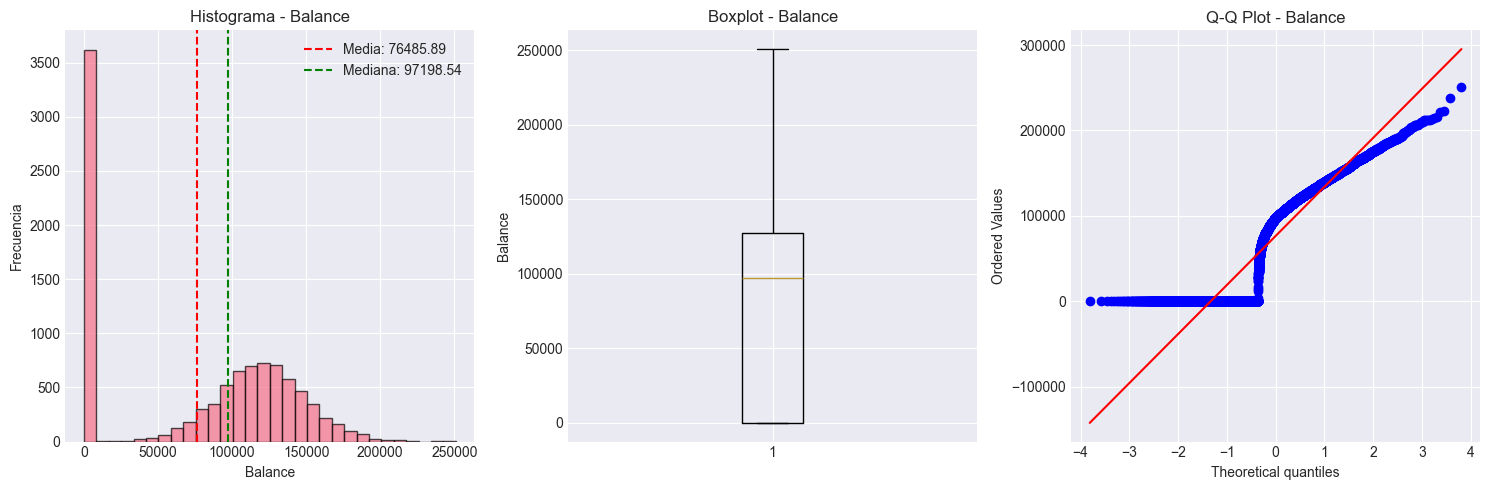


ANÁLISIS UNIVARIABLE: EstimatedSalary

Estadísticas Descriptivas:
  Media............... 100090.2399
  Mediana............. 100193.9150
  Moda................ 24924.9200
  Desv_Std............ 57510.4928
  Varianza............ 3307456784.1345
  Rango............... 199980.9000
  IQR................. 98386.1375
  Skewness............ 0.0021
  Kurtosis............ -1.1815
  Min................. 11.5800
  Q1.................. 51002.1100
  Q3.................. 149388.2475
  Max................. 199992.4800

  → Distribución: aproximadamente simétrica


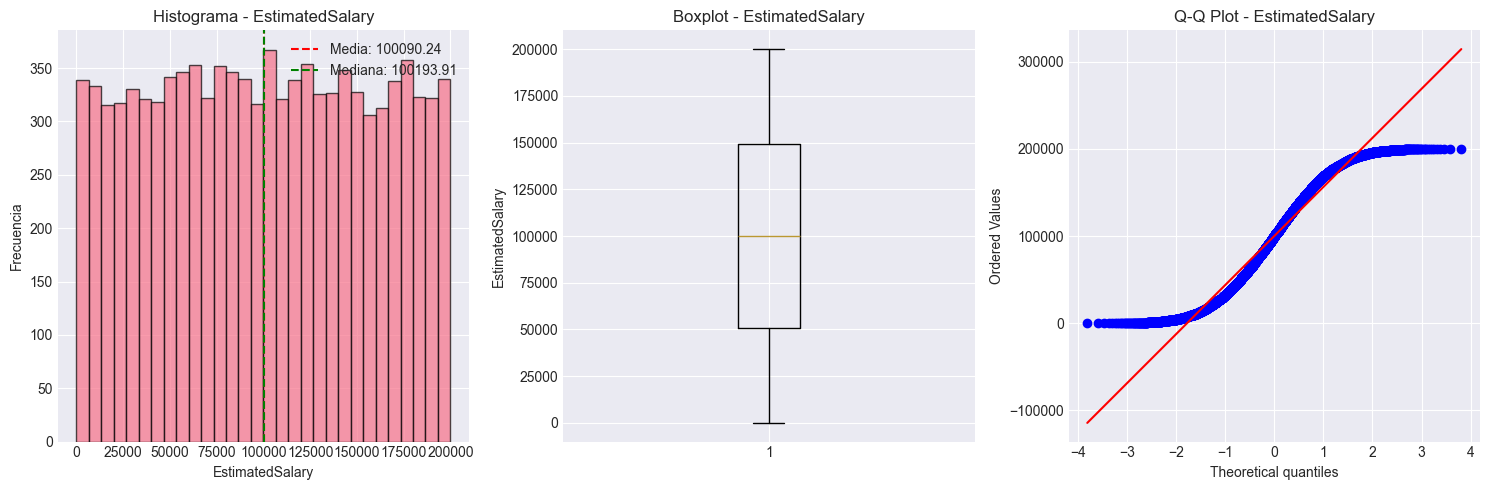

In [18]:
# Análisis de variables numéricas continuas
numerical_continuous = [col for col in var_classification['numerical_continuous'] 
                       if col in df_clean.columns]

if numerical_continuous:
    numerical_stats = univariate_numerical_analysis(df_clean, numerical_continuous)


ANÁLISIS UNIVARIABLE: CreditScore

Estadísticas Descriptivas:
  Media............... 650.5288
  Mediana............. 652.0000
  Moda................ 850.0000
  Desv_Std............ 96.6533
  Varianza............ 9341.8602
  Rango............... 500.0000
  IQR................. 134.0000
  Skewness............ -0.0716
  Kurtosis............ -0.4261
  Min................. 350.0000
  Q1.................. 584.0000
  Q3.................. 718.0000
  Max................. 850.0000

  → Distribución: aproximadamente simétrica


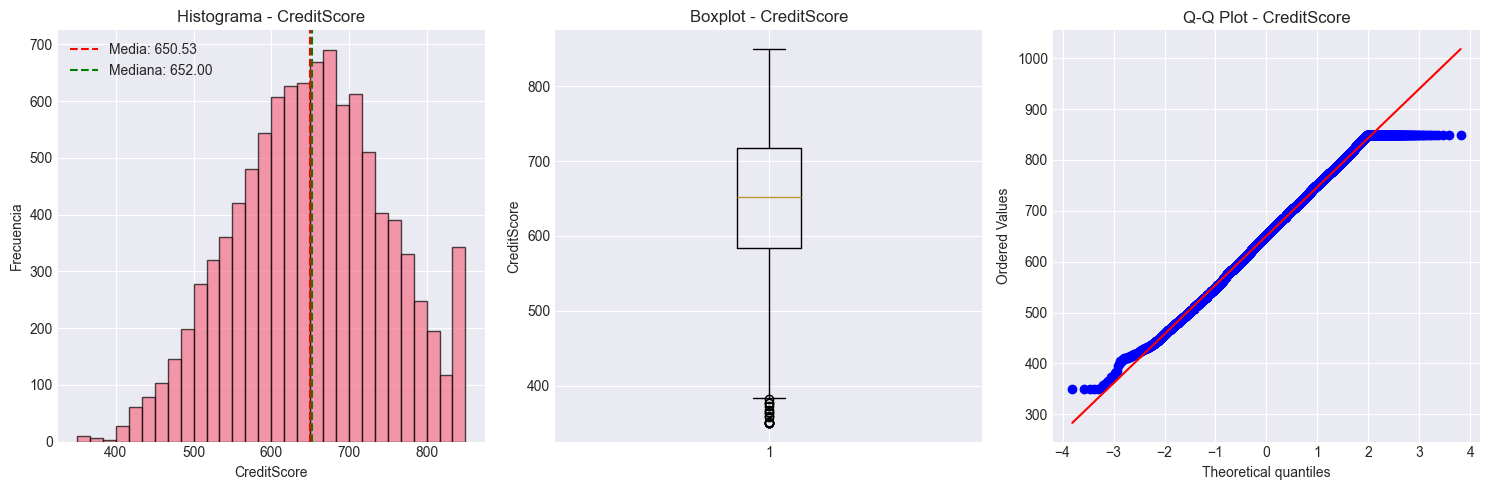


ANÁLISIS UNIVARIABLE: Age

Estadísticas Descriptivas:
  Media............... 38.9218
  Mediana............. 37.0000
  Moda................ 37.0000
  Desv_Std............ 10.4878
  Varianza............ 109.9941
  Rango............... 74.0000
  IQR................. 12.0000
  Skewness............ 1.0112
  Kurtosis............ 1.3940
  Min................. 18.0000
  Q1.................. 32.0000
  Q3.................. 44.0000
  Max................. 92.0000

  → Distribución: sesgada a la derecha (positiva)


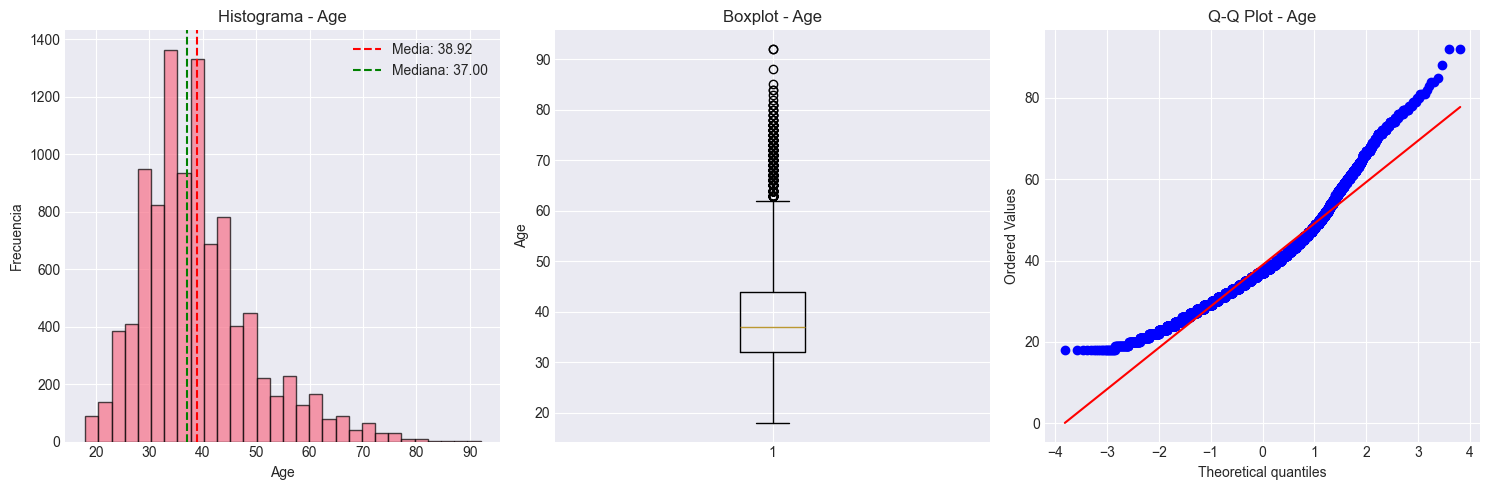


ANÁLISIS UNIVARIABLE: Tenure

Estadísticas Descriptivas:
  Media............... 5.0128
  Mediana............. 5.0000
  Moda................ 2.0000
  Desv_Std............ 2.8922
  Varianza............ 8.3647
  Rango............... 10.0000
  IQR................. 4.0000
  Skewness............ 0.0110
  Kurtosis............ -1.1652
  Min................. 0.0000
  Q1.................. 3.0000
  Q3.................. 7.0000
  Max................. 10.0000

  → Distribución: aproximadamente simétrica


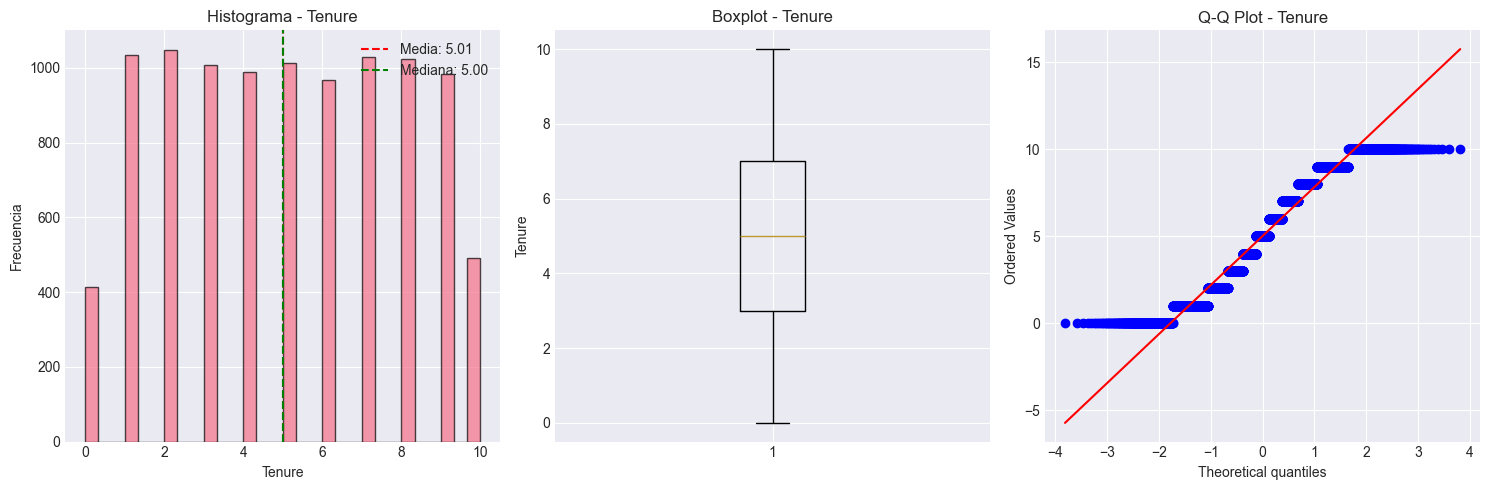


ANÁLISIS UNIVARIABLE: NumOfProducts

Estadísticas Descriptivas:
  Media............... 1.5302
  Mediana............. 1.0000
  Moda................ 1.0000
  Desv_Std............ 0.5817
  Varianza............ 0.3383
  Rango............... 3.0000
  IQR................. 1.0000
  Skewness............ 0.7455
  Kurtosis............ 0.5821
  Min................. 1.0000
  Q1.................. 1.0000
  Q3.................. 2.0000
  Max................. 4.0000

  → Distribución: sesgada a la derecha (positiva)


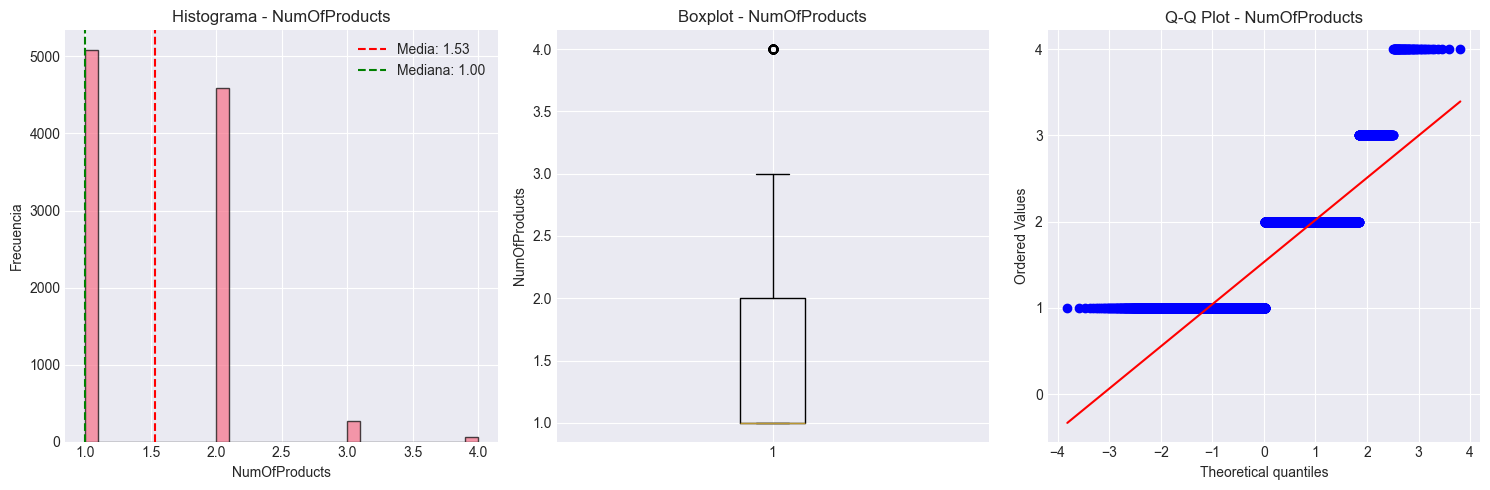

In [19]:
# Análisis de variables numéricas discretas
numerical_discrete = [col for col in var_classification['numerical_discrete'] 
                     if col in df_clean.columns and col != TARGET_COLUMN]

if numerical_discrete:
    discrete_stats = univariate_numerical_analysis(df_clean, numerical_discrete)


ANÁLISIS UNIVARIABLE: Geography

Distribución de Geography:



,Frecuencia,Porcentaje
Geography,,
France,5014,50.14
Germany,2509,25.09
Spain,2477,24.77


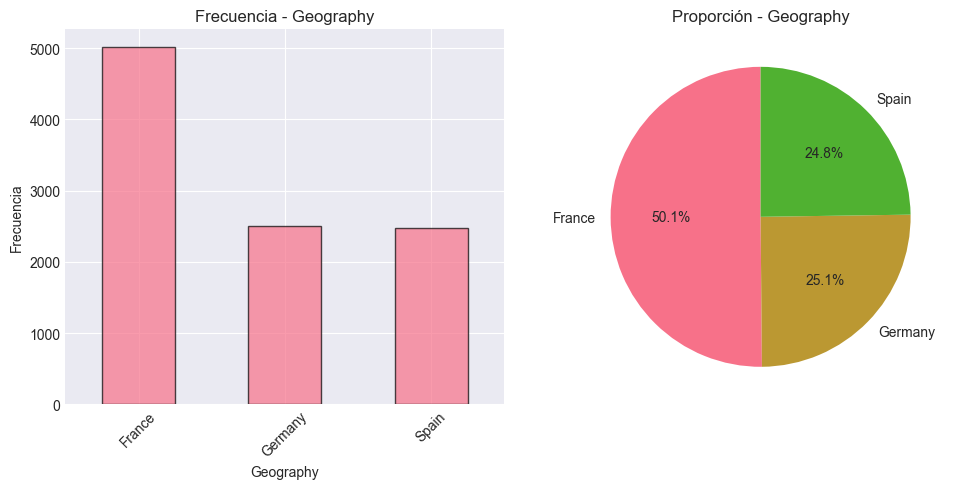


ANÁLISIS UNIVARIABLE: Gender

Distribución de Gender:



,Frecuencia,Porcentaje
Gender,,
Male,5457,54.57
Female,4543,45.43


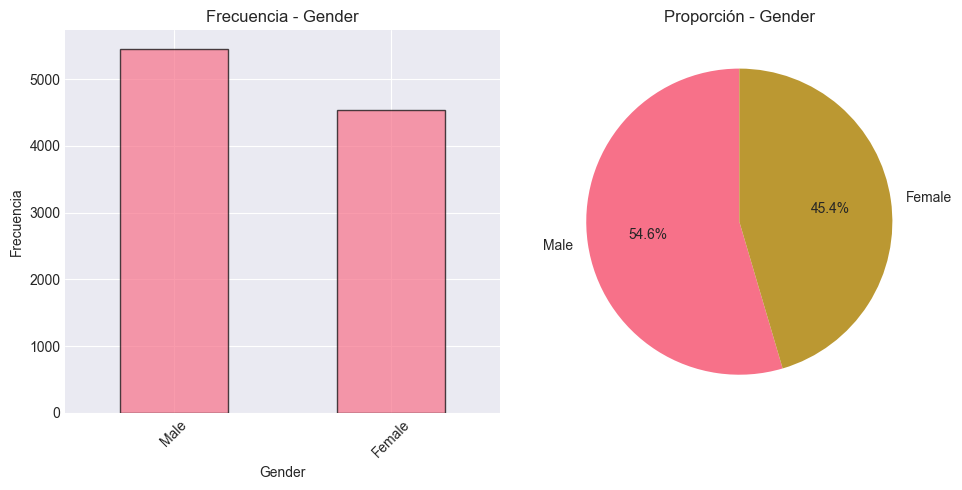


ANÁLISIS UNIVARIABLE: HasCrCard

Distribución de HasCrCard:



,Frecuencia,Porcentaje
HasCrCard,,
1,7055,70.55
0,2945,29.45


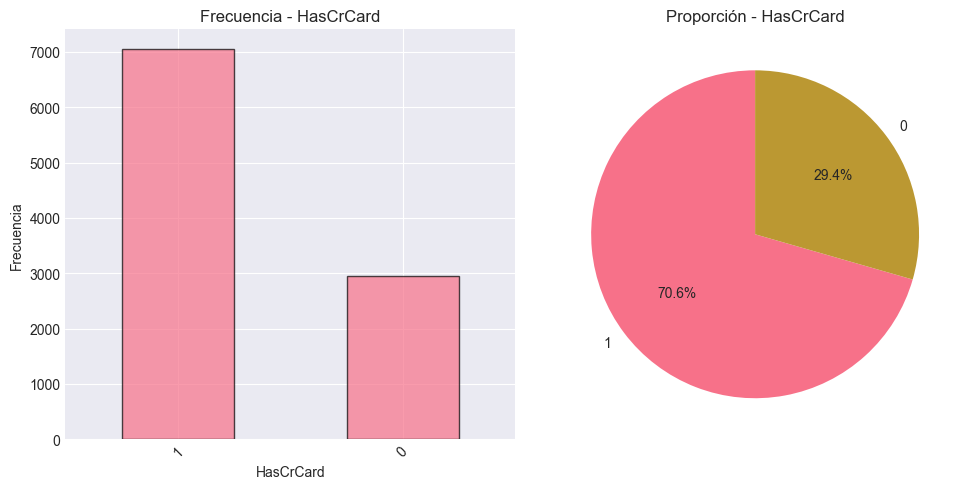


ANÁLISIS UNIVARIABLE: IsActiveMember

Distribución de IsActiveMember:



,Frecuencia,Porcentaje
IsActiveMember,,
1,5151,51.51
0,4849,48.49


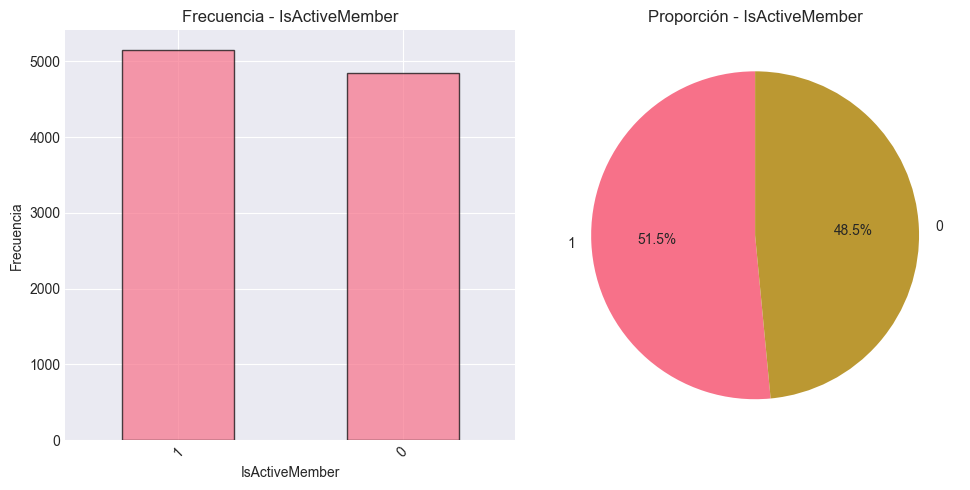

In [20]:
# Análisis de variables categóricas
categorical_all = [col for col in var_classification['categorical_nominal'] + 
                   var_classification['categorical_binary'] 
                   if col in df_clean.columns and col != TARGET_COLUMN]

if categorical_all:
    categorical_freq = univariate_categorical_analysis(df_clean, categorical_all)


ANÁLISIS DE VARIABLE OBJETIVO: Exited

Distribución del Target:
  0: 7,963 (79.63%)
  1: 2,037 (20.37%)

Ratio de balance: 0.26
⚠ ADVERTENCIA: Dataset desbalanceado. Considerar técnicas de balanceo (SMOTE, etc.)


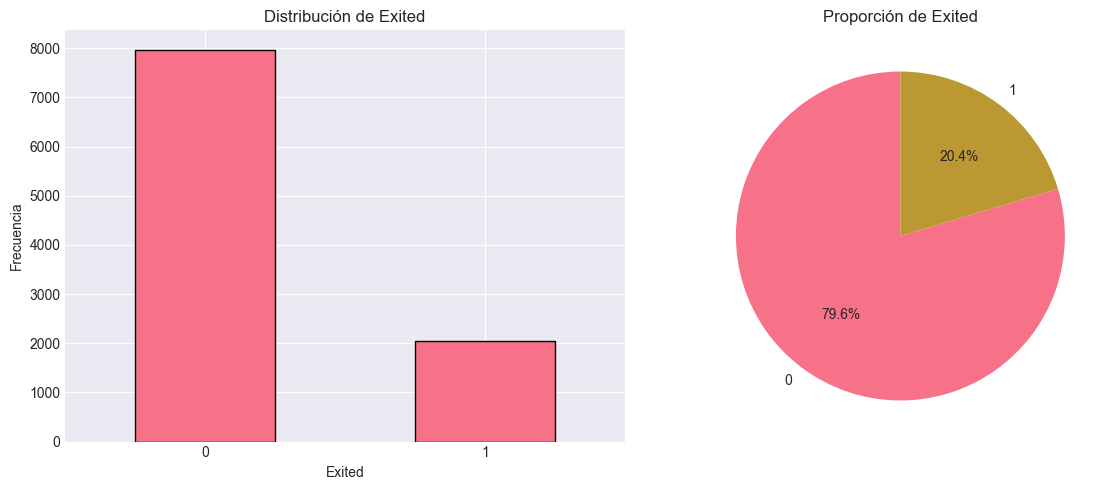

In [21]:
# Análisis del Target
print("\n" + "="*70)
print(f"ANÁLISIS DE VARIABLE OBJETIVO: {TARGET_COLUMN}")
print("="*70)

target_dist = df_clean[TARGET_COLUMN].value_counts()
target_pct = df_clean[TARGET_COLUMN].value_counts(normalize=True) * 100

print("\nDistribución del Target:")
for val, count, pct in zip(target_dist.index, target_dist.values, target_pct.values):
    print(f"  {val}: {count:,} ({pct:.2f}%)")

# Verificar desbalance
if len(target_dist) == 2:
    balance_ratio = target_dist.min() / target_dist.max()
    print(f"\nRatio de balance: {balance_ratio:.2f}")
    if balance_ratio < 0.3:
        print("⚠ ADVERTENCIA: Dataset desbalanceado. Considerar técnicas de balanceo (SMOTE, etc.)")

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
target_dist.plot(kind='bar', ax=axes[0], edgecolor='black')
axes[0].set_title(f'Distribución de {TARGET_COLUMN}')
axes[0].set_xlabel(TARGET_COLUMN)
axes[0].set_ylabel('Frecuencia')
axes[0].tick_params(axis='x', rotation=0)

axes[1].pie(target_dist, labels=target_dist.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title(f'Proporción de {TARGET_COLUMN}')

plt.tight_layout()
plt.show()

## 4. Análisis Bivariable y Multivariable


ANÁLISIS BIVARIABLE CON VARIABLE OBJETIVO: Exited

[1] Variables Numéricas vs Target
----------------------------------------------------------------------

→ Balance vs Exited


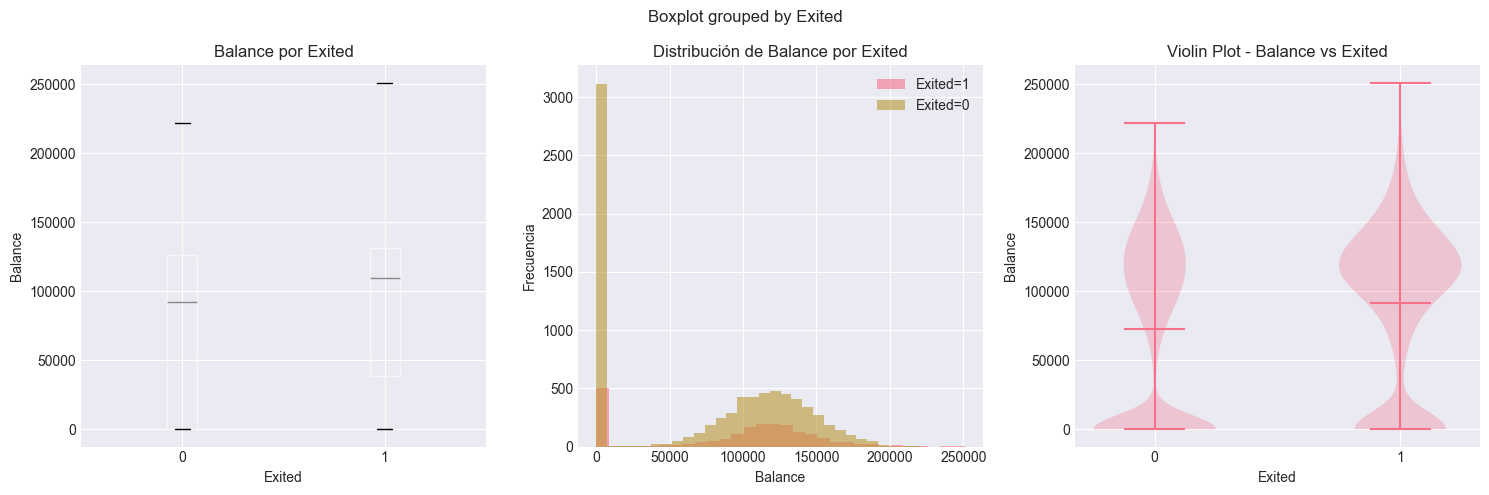


Estadísticas de Balance por Exited:


,count,mean,std,min,25%,50%,75%,max
Exited,,,,,,,,
0,7963.0,72745.296779,62848.040701,0.0,0.00,92072.68,126410.28,221532.80
1,2037.0,91108.539337,58360.794816,0.0,38340.02,109349.29,131433.33,250898.09



→ EstimatedSalary vs Exited


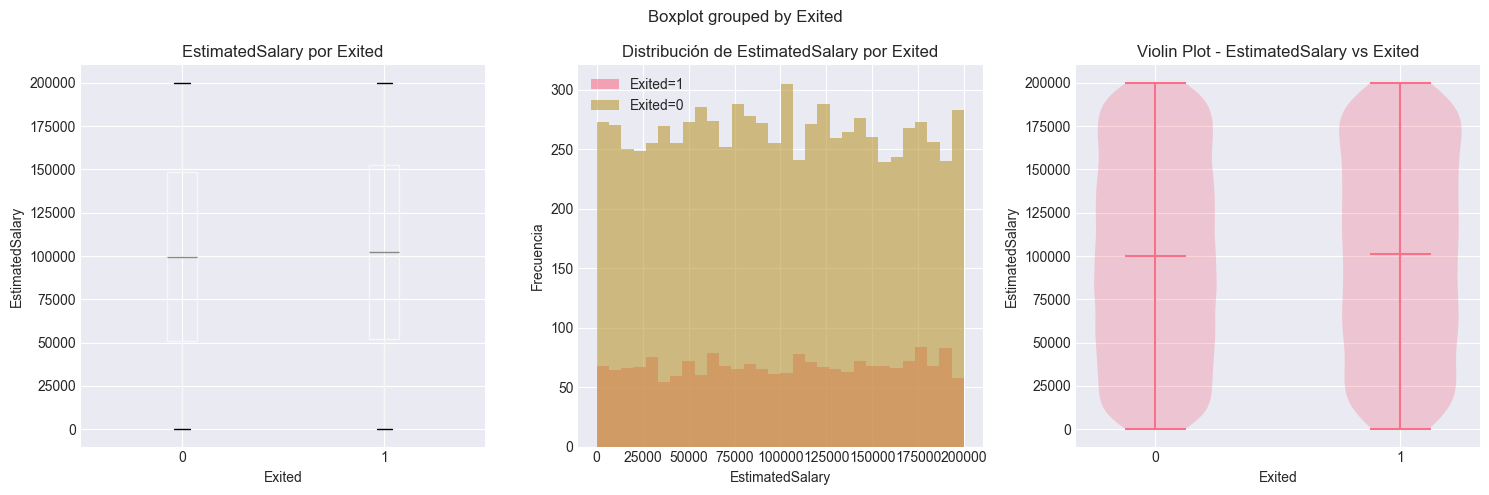


Estadísticas de EstimatedSalary por Exited:


,count,mean,std,min,25%,50%,75%,max
Exited,,,,,,,,
0,7963.0,99738.391772,57405.586966,90.07,50783.49,99645.04,148609.955,199992.48
1,2037.0,101465.677531,57912.418071,11.58,51907.72,102460.84,152422.910,199808.10



→ CreditScore vs Exited


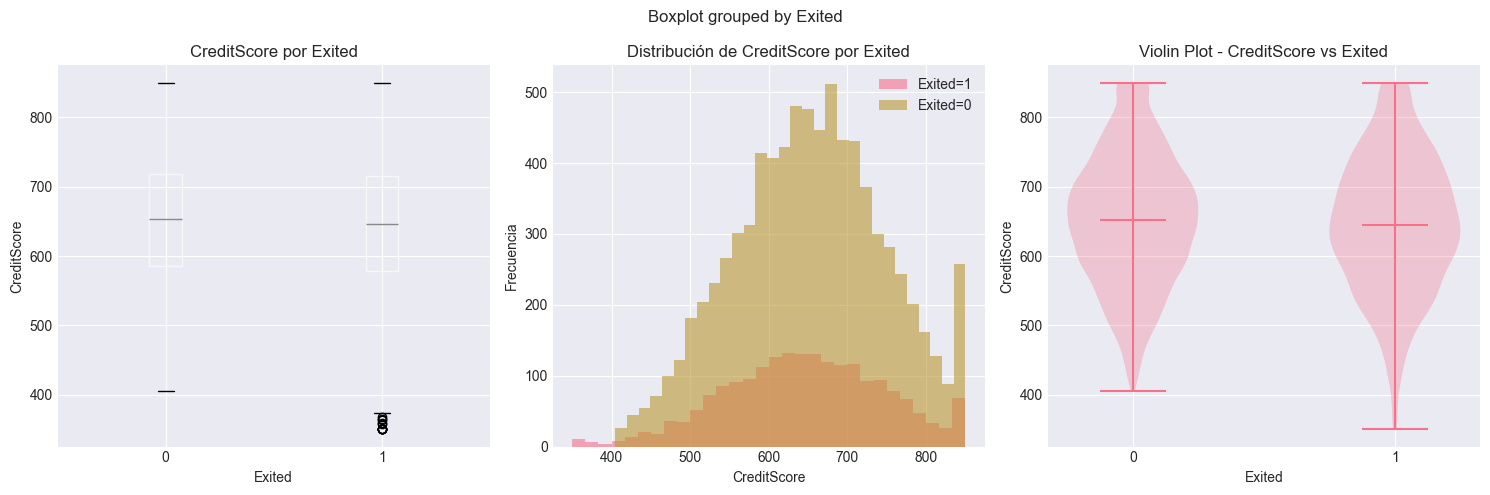


Estadísticas de CreditScore por Exited:


,count,mean,std,min,25%,50%,75%,max
Exited,,,,,,,,
0,7963.0,651.853196,95.653837,405.0,585.0,653.0,718.0,850.0
1,2037.0,645.351497,100.321503,350.0,578.0,646.0,716.0,850.0



→ Age vs Exited


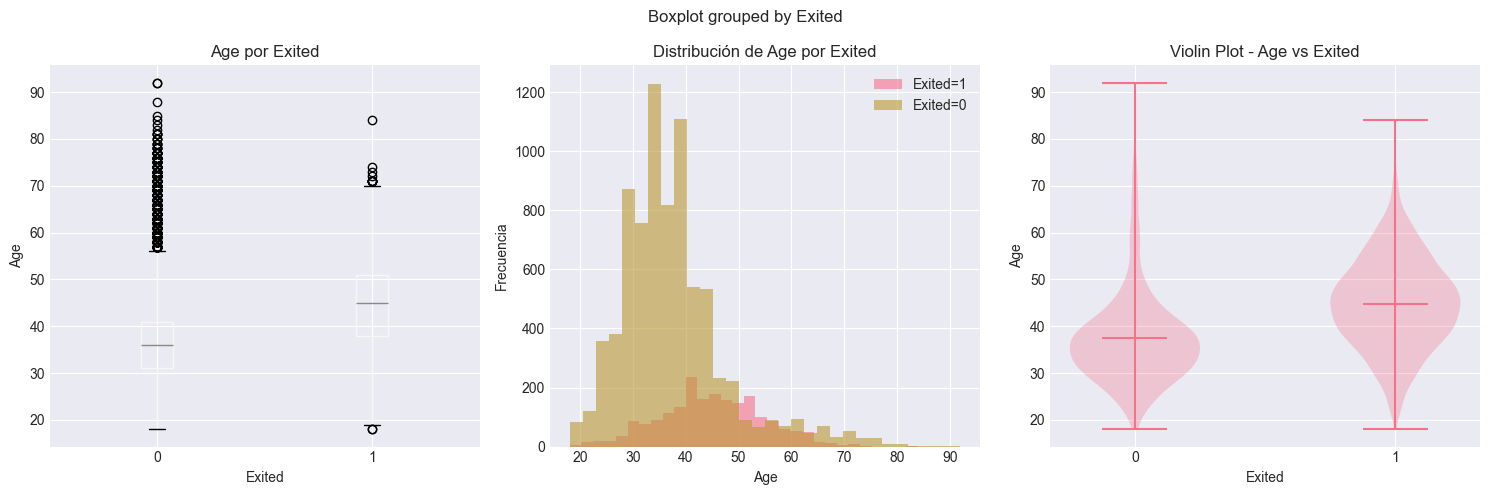


Estadísticas de Age por Exited:


,count,mean,std,min,25%,50%,75%,max
Exited,,,,,,,,
0,7963.0,37.408389,10.125363,18.0,31.0,36.0,41.0,92.0
1,2037.0,44.837997,9.761562,18.0,38.0,45.0,51.0,84.0



→ Tenure vs Exited


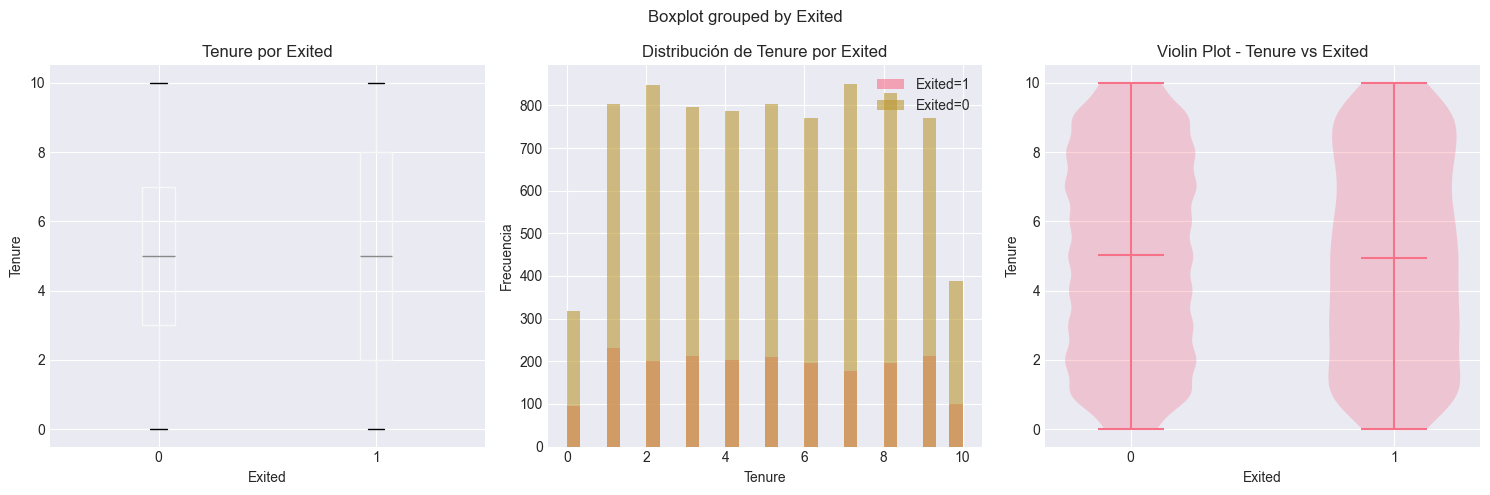


Estadísticas de Tenure por Exited:


,count,mean,std,min,25%,50%,75%,max
Exited,,,,,,,,
0,7963.0,5.033279,2.880658,0.0,3.0,5.0,7.0,10.0
1,2037.0,4.932744,2.936106,0.0,2.0,5.0,8.0,10.0



→ NumOfProducts vs Exited


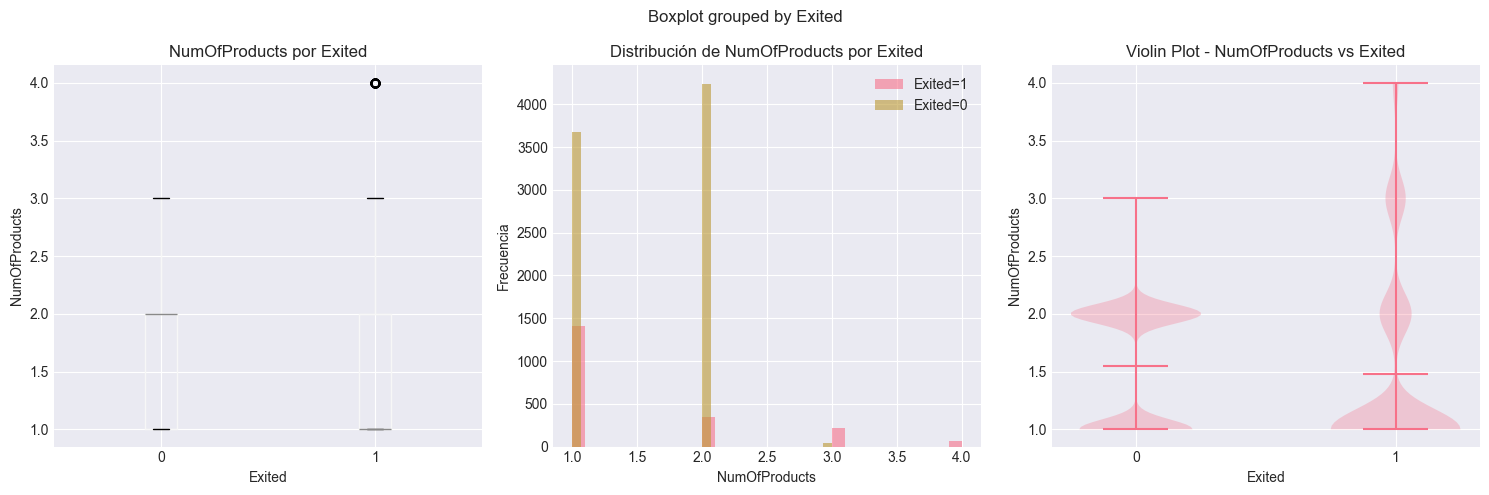


Estadísticas de NumOfProducts por Exited:


,count,mean,std,min,25%,50%,75%,max
Exited,,,,,,,,
0,7963.0,1.544267,0.509536,1.0,1.0,2.0,2.0,3.0
1,2037.0,1.475209,0.801521,1.0,1.0,1.0,2.0,4.0



[2] Variables Categóricas vs Target
----------------------------------------------------------------------

→ Geography vs Exited

Tabla de Frecuencias:


Exited,0,1,All
Geography,,,
France,4204,810,5014
Germany,1695,814,2509
Spain,2064,413,2477
All,7963,2037,10000



Tabla de Porcentajes (por fila):


Exited,0,1
Geography,,
France,83.845233,16.154767
Germany,67.556796,32.443204
Spain,83.326605,16.673395



Test Chi-cuadrado:
  Chi2 = 301.2553
  p-value = 0.0000
  → Existe asociación significativa entre Geography y Exited


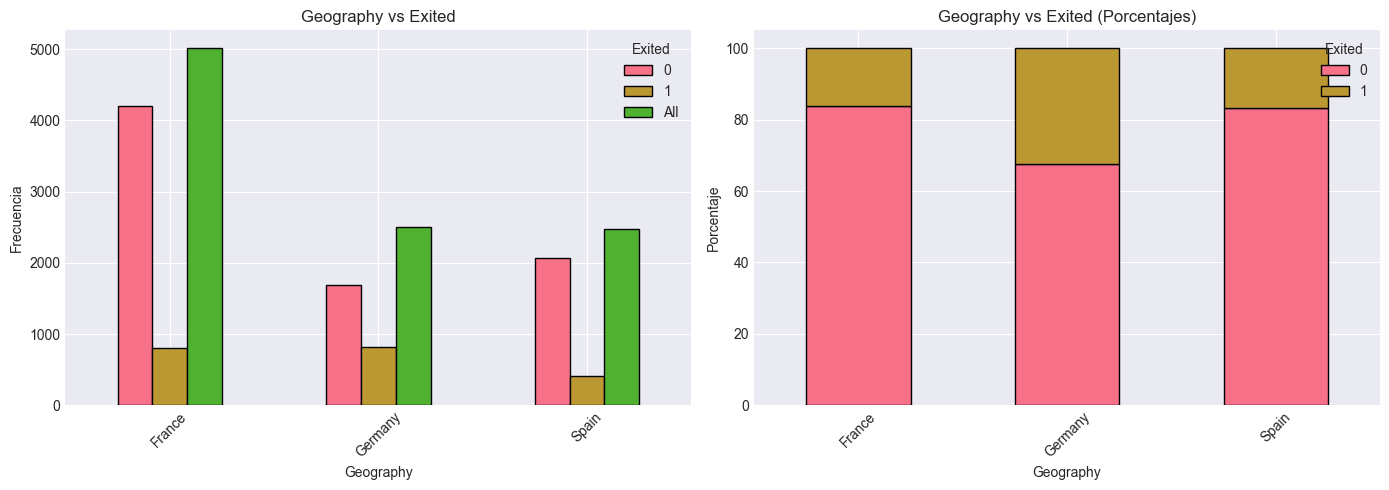


→ Gender vs Exited

Tabla de Frecuencias:


Exited,0,1,All
Gender,,,
Female,3404,1139,4543
Male,4559,898,5457
All,7963,2037,10000



Tabla de Porcentajes (por fila):


Exited,0,1
Gender,,
Female,74.928461,25.071539
Male,83.544072,16.455928



Test Chi-cuadrado:
  Chi2 = 112.9186
  p-value = 0.0000
  → Existe asociación significativa entre Gender y Exited


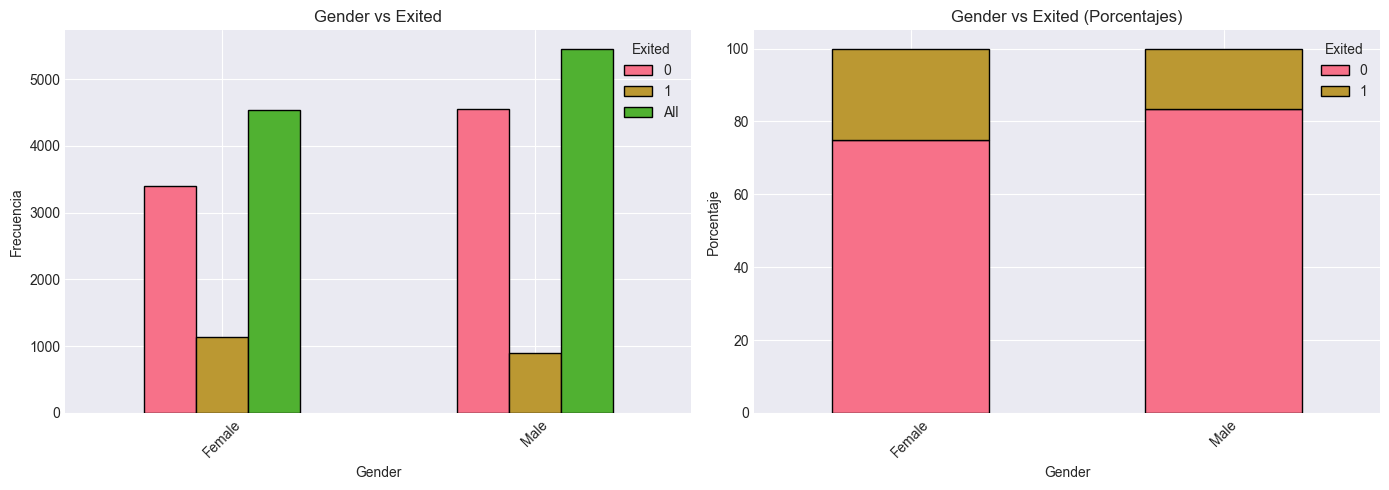


→ HasCrCard vs Exited

Tabla de Frecuencias:


Exited,0,1,All
HasCrCard,,,
0,2332,613,2945
1,5631,1424,7055
All,7963,2037,10000



Tabla de Porcentajes (por fila):


Exited,0,1
HasCrCard,,
0,79.185059,20.814941
1,79.815734,20.184266



Test Chi-cuadrado:
  Chi2 = 0.4713
  p-value = 0.4924
  → No hay asociación significativa entre HasCrCard y Exited


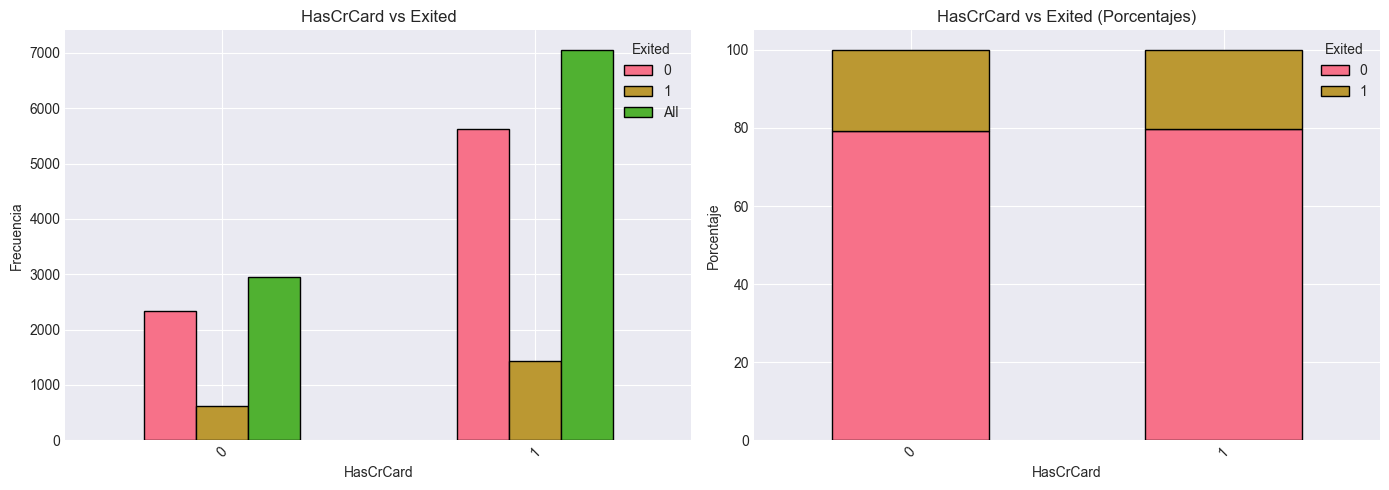


→ IsActiveMember vs Exited

Tabla de Frecuencias:


Exited,0,1,All
IsActiveMember,,,
0,3547,1302,4849
1,4416,735,5151
All,7963,2037,10000



Tabla de Porcentajes (por fila):


Exited,0,1
IsActiveMember,,
0,73.149103,26.850897
1,85.730926,14.269074



Test Chi-cuadrado:
  Chi2 = 242.9853
  p-value = 0.0000
  → Existe asociación significativa entre IsActiveMember y Exited


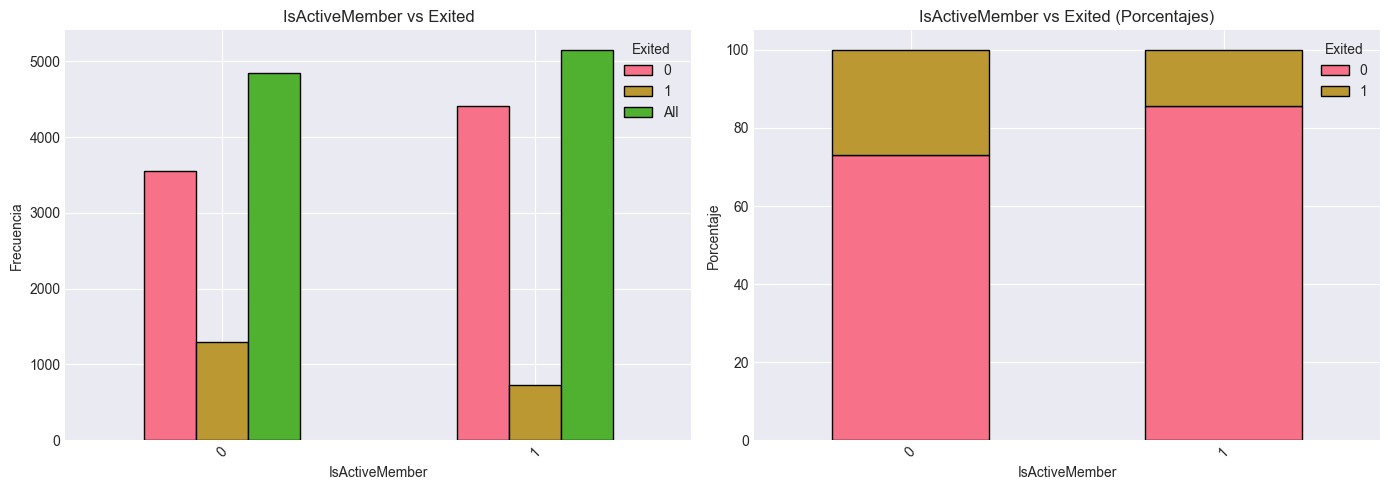

In [22]:
# Análisis bivariable con el target
all_numerical = [col for col in numerical_continuous + numerical_discrete 
                if col in df_clean.columns]

all_categorical = [col for col in categorical_all 
                  if col in df_clean.columns]

bivariate_analysis(df_clean, TARGET_COLUMN, all_numerical, all_categorical)


ANÁLISIS DE CORRELACIÓN


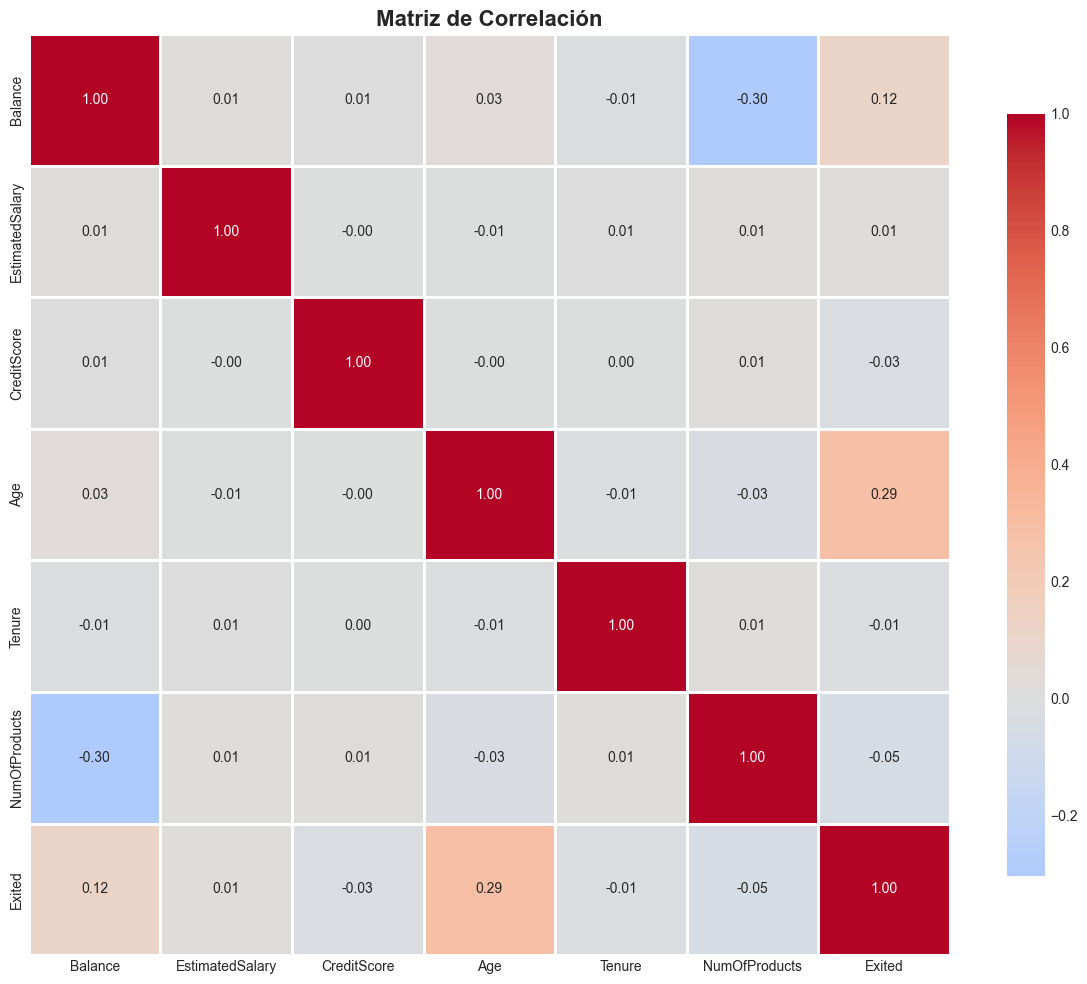


Correlaciones más altas (|r| > 0.5):
  No se encontraron correlaciones altas


In [23]:
# Análisis de correlación
if all_numerical:
    corr_matrix = correlation_analysis(df_clean, all_numerical + [TARGET_COLUMN])


ANÁLISIS MULTIVARIABLE - PAIRPLOT

Top 5 variables correlacionadas con Exited:
  - Age: 0.285
  - Balance: 0.119
  - NumOfProducts: 0.048
  - CreditScore: 0.027
  - Tenure: 0.014


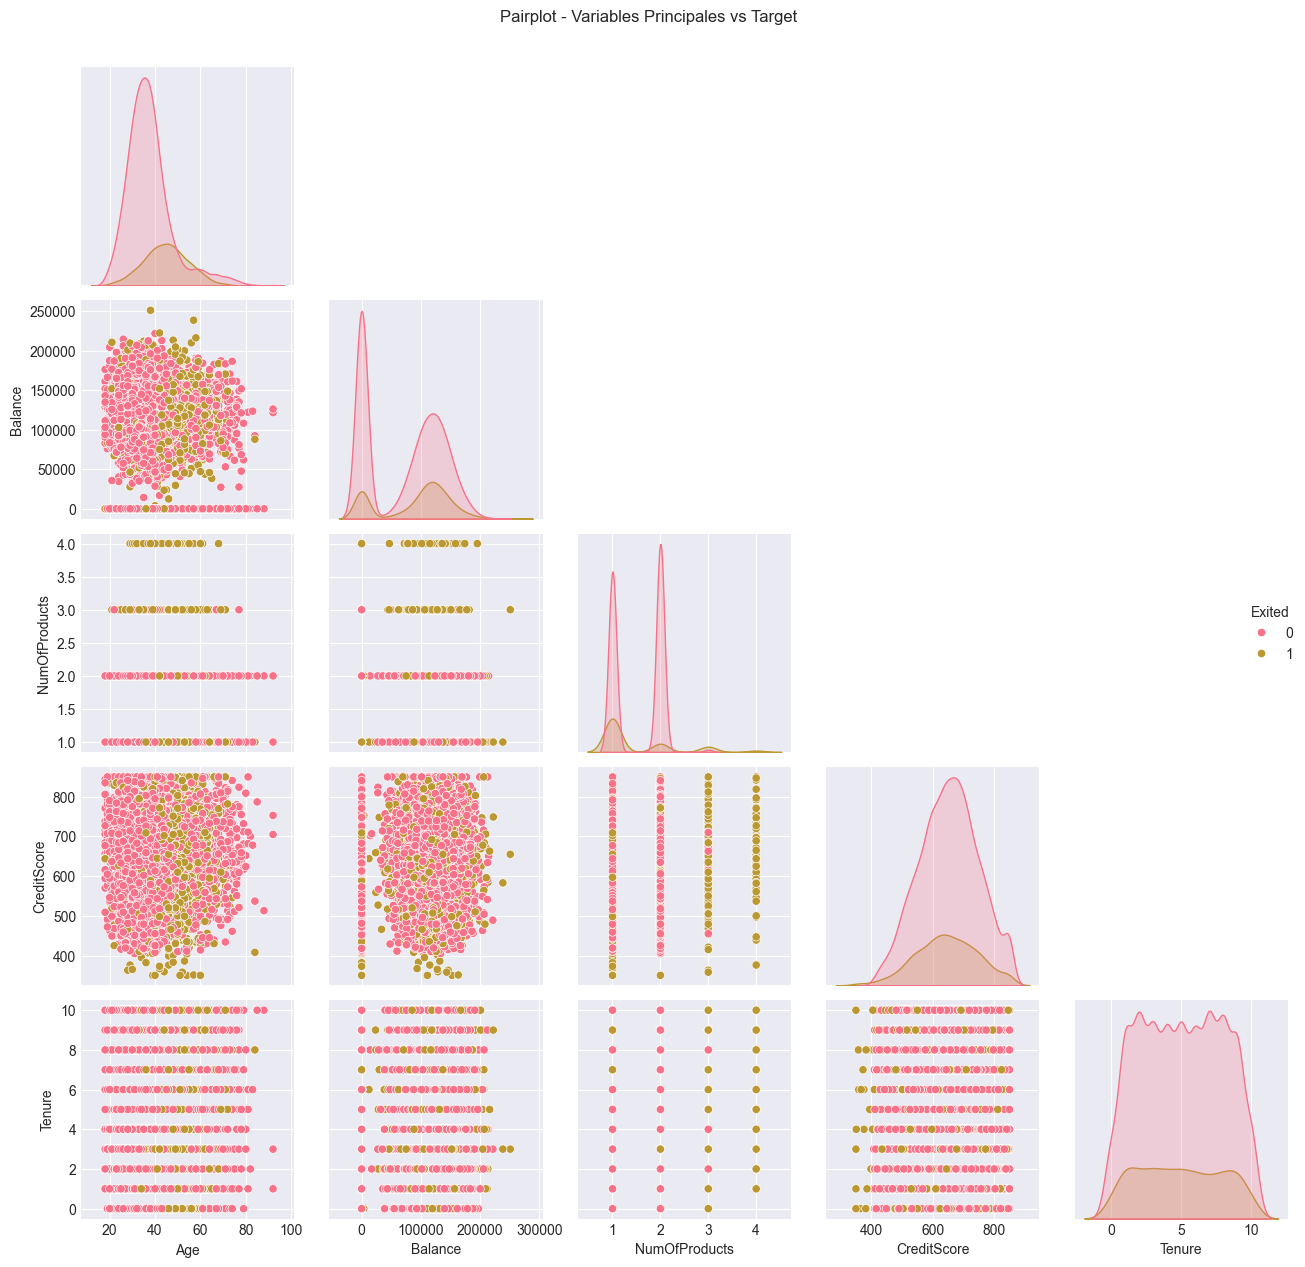

In [24]:
# Pairplot para visualización multivariable (seleccionar variables más relevantes)
print("\n" + "="*70)
print("ANÁLISIS MULTIVARIABLE - PAIRPLOT")
print("="*70)

# Seleccionar top variables correlacionadas con target
if all_numerical and TARGET_COLUMN in df_clean.columns:
    target_corr = df_clean[all_numerical + [TARGET_COLUMN]].corr()[TARGET_COLUMN].abs().sort_values(ascending=False)
    top_features = target_corr.head(6).index.tolist()  # Top 5 + target
    
    print(f"\nTop 5 variables correlacionadas con {TARGET_COLUMN}:")
    for feat in top_features[1:]:  # Excluir el target mismo
        print(f"  - {feat}: {target_corr[feat]:.3f}")
    
    # Crear pairplot
    sns.pairplot(df_clean[top_features], hue=TARGET_COLUMN, diag_kind='kde', corner=True)
    plt.suptitle('Pairplot - Variables Principales vs Target', y=1.01)
    plt.tight_layout()
    plt.show()

## 5. Definición de Reglas de Validación

In [25]:
# Actualizar clasificación con dataset limpio
var_classification_clean = classify_variables(df_clean, target_col=TARGET_COLUMN)

# Definir reglas de validación
validation_rules = define_validation_rules(df_clean, var_classification_clean)


CLASIFICACIÓN DE VARIABLES

NUMERICAL CONTINUOUS (2):
  - Balance
  - EstimatedSalary

NUMERICAL DISCRETE (4):
  - CreditScore
  - Age
  - Tenure
  - NumOfProducts

CATEGORICAL NOMINAL (1):
  - Geography

CATEGORICAL BINARY (3):
  - Gender
  - HasCrCard
  - IsActiveMember

TARGET (1):
  - Exited

REGLAS DE VALIDACIÓN DE DATOS

Resumen de reglas definidas:

Balance:
  tipo: numérico
  min_valido: 0.0
  max_valido: 185967.98540000003
  permite_nulos: False
  debe_ser_positivo: True

EstimatedSalary:
  tipo: numérico
  min_valido: 1842.8253000000004
  max_valido: 198069.7345
  permite_nulos: False
  debe_ser_positivo: True

CreditScore:
  tipo: numérico
  min_valido: 432.0
  max_valido: 850.0
  permite_nulos: False
  debe_ser_positivo: True

Age:
  tipo: numérico
  min_valido: 21.0
  max_valido: 72.0
  permite_nulos: False
  debe_ser_positivo: True

Tenure:
  tipo: numérico
  min_valido: 0.0
  max_valido: 10.0
  permite_nulos: False
  debe_ser_positivo: True

NumOfProducts:
  tipo: numér

## 6. Recomendaciones para Feature Engineering

In [26]:
# Combinar estadísticas de todas las variables numéricas
all_stats = {}
if 'numerical_stats' in locals():
    all_stats.update(numerical_stats)
if 'discrete_stats' in locals():
    all_stats.update(discrete_stats)

# Generar recomendaciones
fe_suggestions = suggest_feature_engineering(df_clean, var_classification_clean, all_stats)


RECOMENDACIONES PARA FEATURE ENGINEERING

[1] Transformaciones sugeridas:
  ✓ Aplicar transformación logarítmica o Box-Cox a 'Age' (skewness=1.01)

[2] Codificación de variables categóricas:
  ✓ Aplicar One-Hot Encoding a 'Geography' (3 categorías)
  ✓ Aplicar Label Encoding a 'Gender' (binaria)
  ✓ Aplicar Label Encoding a 'HasCrCard' (binaria)
  ✓ Aplicar Label Encoding a 'IsActiveMember' (binaria)

[3] Escalado de variables:
  ✓ Aplicar StandardScaler o MinMaxScaler a variables numéricas (6 vars)

[4] Estrategias de imputación:

[5] Features derivados sugeridos:
  ✓ Crear interacciones entre variables relevantes identificadas en el análisis bivariable
  ✓ Crear bins o categorías para variables continuas con patrones claros


## 7. Resumen Final y Exportación

In [27]:
print("\n" + "="*70)
print("RESUMEN EJECUTIVO DEL EDA")
print("="*70)

print(f"\n[DATASET]")
print(f"  Registros: {df_clean.shape[0]:,}")
print(f"  Variables: {df_clean.shape[1]}")
print(f"  Variable Objetivo: {TARGET_COLUMN}")

print(f"\n[TIPOS DE VARIABLES]")
for var_type, cols in var_classification_clean.items():
    if cols:
        print(f"  {var_type.replace('_', ' ').title()}: {len(cols)}")

print(f"\n[CALIDAD DE DATOS]")
total_nulls = df_clean.isnull().sum().sum()
print(f"  Valores nulos totales: {total_nulls}")
print(f"  Duplicados: {df_clean.duplicated().sum()}")

print(f"\n[PRINCIPALES HALLAZGOS]")
print(f"  - Se identificaron {len(validation_rules)} reglas de validación")
print(f"  - Se generaron {len(fe_suggestions)} recomendaciones para feature engineering")
print(f"  - Dataset limpio y listo para la siguiente etapa")

print(f"\n" + "="*70)
print("✓ EDA COMPLETADO EXITOSAMENTE")
print("→ Continuar con ft_engineering.py")
print("="*70)


RESUMEN EJECUTIVO DEL EDA

[DATASET]
  Registros: 10,000
  Variables: 11
  Variable Objetivo: Exited

[TIPOS DE VARIABLES]
  Numerical Continuous: 2
  Numerical Discrete: 4
  Categorical Nominal: 1
  Categorical Binary: 3
  Target: 1

[CALIDAD DE DATOS]
  Valores nulos totales: 0
  Duplicados: 0

[PRINCIPALES HALLAZGOS]
  - Se identificaron 10 reglas de validación
  - Se generaron 8 recomendaciones para feature engineering
  - Dataset limpio y listo para la siguiente etapa

✓ EDA COMPLETADO EXITOSAMENTE
→ Continuar con ft_engineering.py


In [28]:
# Guardar dataset limpio para la siguiente etapa
output_path = PROJECT_ROOT / 'data' / 'processed' / 'data_cleaned.csv'
df_clean.to_csv(output_path, index=False)
print(f"\n✓ Dataset limpio guardado en: {output_path}")


✓ Dataset limpio guardado en: c:\Users\Asus\Desktop\Proyecto\data\processed\data_cleaned.csv


In [29]:
# Guardar metadatos del EDA
import json

eda_metadata = {
    'variable_classification': var_classification_clean,
    'validation_rules': {k: {k2: str(v2) if not isinstance(v2, (int, float, bool)) else v2 
                            for k2, v2 in v.items()} 
                        for k, v in validation_rules.items()},
    'feature_engineering_suggestions': fe_suggestions,
    'target_column': TARGET_COLUMN,
    'dataset_shape': df_clean.shape,
    'columns_removed': columns_to_drop
}

metadata_path = PROJECT_ROOT / 'data' / 'metadata' / 'eda_metadata.json'
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(eda_metadata, f, indent=2, ensure_ascii=False)

print(f"✓ Metadatos del EDA guardados en: {metadata_path}")

✓ Metadatos del EDA guardados en: c:\Users\Asus\Desktop\Proyecto\data\metadata\eda_metadata.json
